# PCA Exercise (Online Dataset) — Template

Dataset: **UCI Wine Quality (red)** (downloaded directly from an online URL).

Goal: Practice a full PCA workflow (centering → covariance → eigenpairs → projection → explained variance → visualization → reconstruction).


## 0. Imports
Run this cell first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


## 1. Load an online dataset
We use the UCI Wine Quality (red) dataset.

**Task:** load the CSV from the URL, inspect the columns, and separate features `X` and label `y`.

- Features: all columns except `quality`
- Label: `quality` (integer score)


In [7]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
# TODO: Load the dataset into a pandas DataFrame called df.
# Hint: the separator is ';'

df = pd.DataFrame(pd.read_csv(url, sep= ";"))

# TODO: Print df.shape and df.head()
print(df.shape)
print(df.head())

# TODO: Create X (numpy array of features) and y (numpy array of quality)
X = df.drop(columns=["quality"]).to_numpy(dtype=float)
y = df["quality"].to_numpy()

# TODO: Print X.shape, y.shape
print("X.shape:", X.shape)
print("y.shape:", y.shape)


(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.

## 2. Implement PCA from scratch
We work with the covariance matrix of **centered** data.

**Math:** If \(X\in\mathbb{R}^{n\times m}\) (rows are samples), let
$$\mu = \frac{1}{n}\sum_{i=1}^n x_i,\quad Y=X-\mathbf{1}\mu^T,\quad S=\frac{1}{n-1}Y^T Y.$$
Then PCA uses eigenpairs \(S u_k=\lambda_k u_k\) with \(\lambda_1\ge\cdots\ge\lambda_m\ge 0\).


In [8]:
# TODO: Implement helper functions.
# 1) center(X) -> (Y, mu)
# 2) covariance_matrix(Y) -> S
# 3) pca_from_cov(S) -> (evals_desc, evecs_desc)

def center(X):
    mu = X.mean(axis=0)
    Y = X - mu
    return Y, mu

def covariance_matrix(Y):
    n = Y.shape[0]
    return (Y.T @ Y) / (n - 1)

def pca_from_cov(S):
    evals, evecs = np.linalg.eigh(S)
    idx = np.argsort(evals)[::-1]
    return evals[idx], evecs[:, idx]

def explained_variance_ratio(evals):
    total = np.sum(evals)
    return evals / total


## 3. Run PCA and compute explained variance
**Task:**
1. Center X → Y
2. Covariance S
3. Eigendecompose S → eigenvalues/eigenvectors
4. Compute explained variance ratio (EVR)
5. Find smallest k such that cumulative EVR ≥ 0.95


In [9]:
# TODO: Run PCA
Y, mu = center(X)
S = covariance_matrix(Y)
evals, U = pca_from_cov(S)

# TODO: EVR
evr = explained_variance_ratio(evals)
cum = np.cumsum(evr)

# TODO: find k95 (smallest k with cum[k-1] >= 0.95)
k95 = np.argmax(cum >= 0.95) +1

# Print: first 10 eigenvalues, first 10 EVR, and k95
print("first 10 eigenvalues:", evals[:10])
print("first 10 EVR:", evr[:10])
print("k95:", k95)


first 10 eigenvalues: [1133.807076   57.935411    3.101302    1.819415    1.04634     0.041397
    0.023193    0.011346    0.010078    0.001455]
first 10 EVR: [0.946577 0.048368 0.002589 0.001519 0.000874 0.000035 0.000019 0.000009
 0.000008 0.000001]
k95: 2


## 4. Visualize EVR and cumulative EVR
**Task:** make two plots:
- bar plot of EVR for the first 10 PCs
- line plot of cumulative EVR for all PCs, with a horizontal line at 0.95


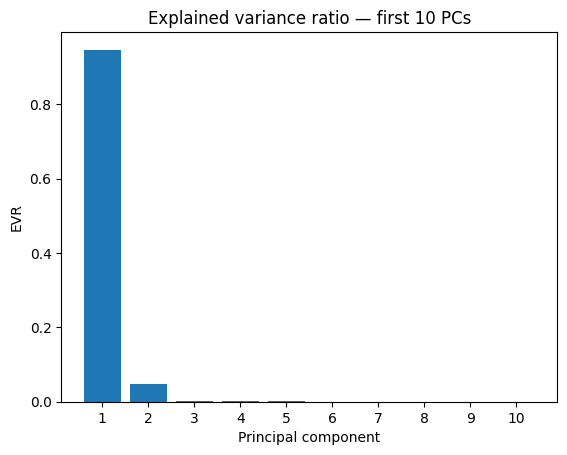

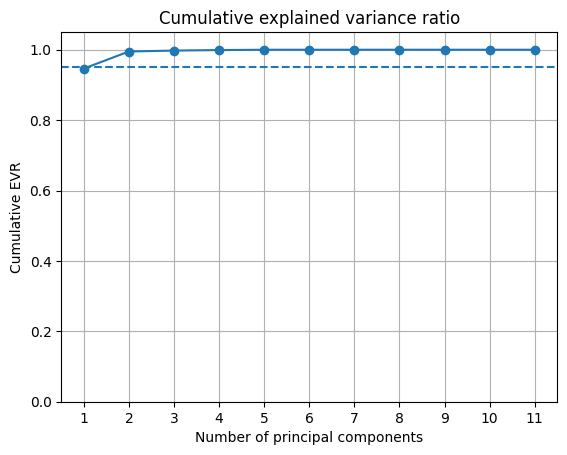

In [10]:
# TODO: Make EVR bar plot (first 10)
num_pcs = min(10, len(evr))

plt.figure()
plt.bar(range(1, num_pcs + 1), evr[:num_pcs])
plt.title("Explained variance ratio — first 10 PCs")
plt.xlabel("Principal component")
plt.ylabel("EVR")
plt.xticks(range(1, num_pcs + 1))
plt.show()

# TODO: Make cumulative EVR line plot (all)

plt.figure()
plt.plot(range(1, len(cum) + 1), cum, marker="o")
plt.axhline(0.95, linestyle="--")
plt.title("Cumulative explained variance ratio")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative EVR")
plt.xticks(range(1, len(cum) + 1))
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


## 5. Project data to 2D (PC1–PC2) and color by quality
**Task:**
- Compute PC scores $Z = Y U_k$
- For a 2D scatter, use $Z_2 = Y [u_1, u_2]$
- Color points by wine quality.


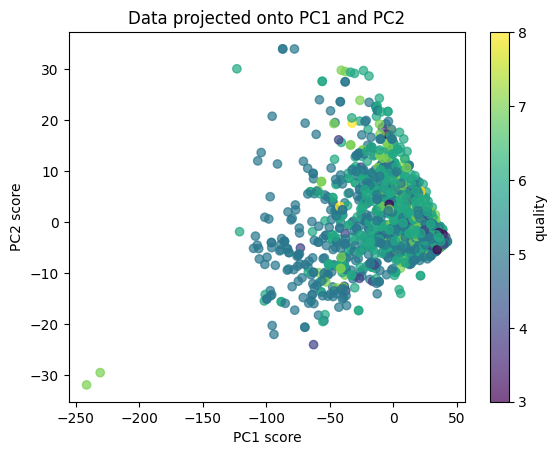

In [12]:
def project(Y, U, k):
    """Project centered data Y (n x m) onto first k PCs (columns of U)."""
    return Y @ U[:, :k]

# TODO: Compute Z2 (n x 2)
Z2 = project(Y, U, k=2)

# TODO: Make a scatter plot of Z2[:,0] vs Z2[:,1] colored by y
plt.figure()
scatter = plt.scatter(Z2[:, 0], Z2[:, 1], c=y, alpha=0.7)
plt.title("Data projected onto PC1 and PC2")
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.colorbar(scatter, label="quality")
plt.show()


## 6. Reconstruction and error vs k
**Task:** for each $k=1,2,\dots,K$ (take $K=10$ or $K=k95$, whichever is smaller):
- $Z_k = YU_k$
- $\hat{X}_k = \mu + Z_k U_k^T$
- MSE = mean squared error over all entries

Plot MSE vs k.


MSE values:
k=1: 5.813629
k=2: 0.550067


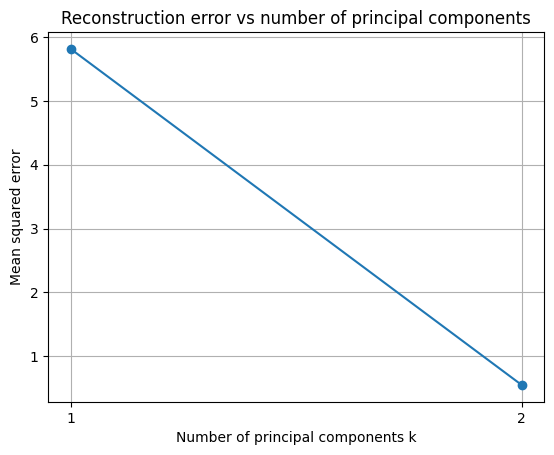

In [15]:
def reconstruct(Z, mu, U, k):
    """Reconstruct from PCA coordinates Z using first k PCs."""
    return mu + Z @ U[:, :k].T

# TODO: Choose K = min(10, k95)
K = min(10, k95)
# TODO: Loop over k=1..K computing reconstruction and MSE
mse_values = []

for k in range(1, K + 1):
    Zk = project(Y, U, k)
    X_hat = reconstruct(Zk, mu, U, k)
    mse = np.mean((X - X_hat) ** 2)
    mse_values.append(mse)

print("MSE values:")
for k, mse in enumerate(mse_values, start=1):
    print(f"k={k}: {mse:.6f}")
# TODO: Plot MSE vs k
plt.figure()
plt.plot(range(1, K + 1), mse_values, marker="o")
plt.title("Reconstruction error vs number of principal components")
plt.xlabel("Number of principal components k")
plt.ylabel("Mean squared error")
plt.xticks(range(1, K + 1))
plt.grid(True)
plt.show()

## 7. Short questions (answer in Markdown)
1. Why do we **center** the data before PCA?
2. What does an eigenvector entry (loading) mean?
3. What does it mean if PC2 has opposite signs for two features?


**Your answers:**

1. Without centering, the covariance matrix and the first principal component could be influenced by the location of the data instead of by the actual spread of the samples.
2. How strongly a given original feature contributes to a principal component.
3. Principal component represents a contrast between them.
